In [2]:
from cellarium.ml import CellariumAnnDataDataModule, CellariumModule
from cellarium.ml.data import read_h5ad_file
from cellarium.ml.data import DistributedAnnDataCollection
from cellarium.ml.utilities.data import AnnDataField, collate_fn, densify, categories_to_codes
from cellarium.ml.callbacks import PredictionWriter
from cellarium.ml.data.dadc_dataset import IterableDistributedAnnDataCollectionDataset
from cellarium.ml.models import ImputationModel, SingleCellVariationalInference

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
import pandas as pd
import numpy as np
import anndata as ad
import glob
import os
import torch
import matplotlib.pyplot as plt
import scanpy as sc
import scipy.sparse as sp
import seaborn as sns
import shutil
import pickle

from sklearn.model_selection import train_test_split
from cellarium.ml.data.fileio import read_h5ad_file

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix


In [3]:
def mask_data(adata, masking_probability, random_seed):
    """
    Randomly mask a fraction of genes per cell in an AnnData object.

    Parameters
    ----------
    adata : AnnData
        Input AnnData object (n_obs x n_vars).
    mask_fraction : float
        Fraction of genes to mask per cell (e.g., 0.2 = 20%).
    mask_value : float or np.nan
        Value to assign to masked positions (default 0.0).
    layer_key : str
        Key in adata.layers where masked data will be stored.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    masked_adata : AnnData
        New AnnData object with:
          - masked counts in `.X` and `.layers[layer_key]`
          - mask matrix in `.layers[f"mask_{int(masking_probability*100)}"]`
          - per-cell mask indices in `.obs[f"masked_gene_indices_{int(masking_probability*100)}"]`
    """

    rng = np.random.default_rng(random_seed)
    
    n_cells, n_genes =  adata.X.shape
    n_mask = int(masking_probability * n_genes)
    print(f"Masking {n_mask} genes out of {n_genes} ({masking_probability*100}%) per cell.")
    
    # Create mask matrix of all zeros of shape (n_cells, n_genes)
    mask = np.zeros(adata.X.shape, dtype=bool)
  
    masked_indices_per_cell = []
    # For each cell, randomly select n_mask gene indices to mask
    for i in range(n_cells):
        # print(f"Processing cell {i+1}/{n_cells}")
        # Randomly choose n_mask unique gene indices
        mask_indices = rng.choice(n_genes, n_mask, replace=False)
        mask[i, mask_indices] = True
        masked_indices_per_cell.append(mask_indices)

    X_masked = adata.X.copy()
    # Apply the mask: set masked positions to 0
    X_masked[mask] = 0

    # Create new AnnData to store masked data and mask matrix
    masked_adata = ad.AnnData(X_masked, obs=adata.obs.copy(), var=adata.var.copy())
    masked_adata.layers["X_masked"] = X_masked
    masked_adata.layers[f"mask_{int(masking_probability*100)}"] = mask.astype(np.int8)
    masked_adata.obsm = adata.obsm.copy()

    # Store which gene indices were masked per cell (as strings for convenience)
    masked_adata.obs[f"masked_gene_indices_{int(masking_probability*100)}"] = [
        ",".join(map(str, idxs)) for idxs in masked_indices_per_cell
    ]

    # Create DataModule for masked data
    dm_mask= CellariumAnnDataDataModule(
            dadc=masked_adata,
            batch_keys={
                "x_ng": AnnDataField(attr="X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch", convert_fn=categories_to_codes),
            },
            batch_size=512,
            shuffle=False,
        )  

    return masked_adata, dm_mask, masked_indices_per_cell

In [4]:
def save_predictions_latent(predictions, prediction_path, adata, label, prob):
    """
    Save prediction latent representations with proper labeling.
    
    Parameters
    ----------
    predictions : list
        List of prediction batches
    prediction_path : str
        Base path for saving predictions
    adata : AnnData
        AnnData object to store results
    label : str
        Label for the predictions ('whole' or 'masked')
    prob : float
        Masking probability used
    """

    # Create subdirectory for this prediction type
    pred_path = os.path.join(prediction_path, label)
    os.makedirs(pred_path, exist_ok=True)
    
    # Load and combine all batches
    dfs = []
    for file in glob.glob(os.path.join(prediction_path, f'batch_*')):
        dfs.append(pd.read_csv(file, index_col=0, header=None))
    latent_df = pd.concat(dfs, axis=0)
    latent_df = latent_df.loc[adata.obs_names]
    
    # Move batch files in prediction_path to pred_path
    batch_files = glob.glob(os.path.join(prediction_path, f'batch_*'))

    for src in batch_files:
        base = os.path.basename(src)
        dest = os.path.join(pred_path, base)
        try:
            shutil.move(src, dest)
        except Exception:
            if os.path.exists(dest):
                try:
                    os.remove(dest)
                except Exception as e:
                    raise RuntimeError(f"Could not remove existing destination {dest}: {e}") from e
            shutil.move(src, dest)

    return latent_df.values

def train_and_predict_imputation(imputation_module, adata, dm, masking_prob, prediction_base_path='runs/imputation'):
    """
    Train imputation model and perform both whole dataset and masked predictions.
    
    Parameters
    ----------
    imputation_module : CellariumModule
        Imputation model to be trained
    adata : AnnData
        Input dataset
    dm : CellariumAnnDataDataModule
        Data module for training
    masking_prob : float
        Probability for masking genes
    prediction_base_path : str
        Base path for storing predictions
        
    Returns
    -------
    dict
        Dictionary containing whole and masked predictions, 
        whole and masked latent representations, 
        and masked gene indices.
    """

    # Setup paths and names
    name_label = f"mask{int(masking_prob*100)}"
    prediction_path = f"{prediction_base_path}/predictions_{name_label}"
    
    # Define imputation module
    print(f"\nDefining imputation module with masking_probability={masking_prob}")
    # Train model
    print(f"Training model...")
    logger = CSVLogger("logs", name=f"imputation_{name_label}")
    trainer = pl.Trainer(
        accelerator="cpu",
        precision="32-true",
        devices=1,
        max_epochs=20,
        default_root_dir=f"runs/imputation_{name_label}/",
        logger=logger,
        callbacks=[PredictionWriter(output_dir=prediction_path)])
    trainer.fit(imputation_module, dm)
    
    # Get metrics from the trained model
    imputation_module.eval()
    batch = next(iter(dm.train_dataloader()))
    batch = {k: v for k, v in batch.items() if k in {"x_ng", "batch_index_n","var_names_g"}}
    print(batch.keys())
    with torch.no_grad():
        metric_outputs = imputation_module.model(**batch)
    print(f"Loss: {metric_outputs['loss'].item():.4f}")
    print(f"Reconstruction Loss: {metric_outputs['reconstruction_loss'].mean().item():.4f}")
    print(f"Noise2Self Rec Loss: {metric_outputs['noise2self_rec_loss_n'].mean().item():.4f}")
    print(f"KL Divergence Z: {metric_outputs['kl_divergence_z'].mean().item():.4f}")
    print(f"KL Annealing Weight: {metric_outputs['kl_annealing_weight']:.4f}")

    # Predict on the whole dataset
    print("Predicting on whole dataset...")
    whole_predictions = trainer.predict(imputation_module, dm)
    whole_collated = collate_fn(whole_predictions)
    latent_whole = save_predictions_latent(whole_collated, prediction_path, adata, 'whole', masking_prob)

    # Create and predict on masked dataset
    print("Predicting on masked dataset...")
    masked_adata, dm_mask, masked_indices = mask_data(dm.dadc, masking_probability=0.5, random_seed=42)
    masked_predictions = trainer.predict(imputation_module, dm_mask)
    masked_collated = collate_fn(masked_predictions)
    latent_masked = save_predictions_latent(masked_collated, prediction_path, adata, 'masked', masking_prob)    
    
    return {
        f"{name_label}_whole": whole_collated,
        f"{name_label}_masked": masked_collated,
        f"{name_label}_latent_whole": latent_whole,
        f"{name_label}_latent_masked":latent_masked,
        f"{name_label}_masked_gene_indices": masked_indices,
        f"{name_label}_output_metrics": metric_outputs
    }


In [5]:
def train_classifiers(X_train, y_train):
    """Train multiple classifier models on the provided training data."""

    # Multinomial Logistic Regression -- this is considered to be a strong baseline model for cell type classification 
    print("Training Logistic Regression model...") 
    lr_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=1000)
    lr_model.fit(X_train, y_train)

    # Random Forest Classifier
    print("Training Random Forest model...")
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    # Support Vector Machine Classifier
    print("Training SVM model...")
    svm_model = SVC(gamma='auto', random_state=42)
    svm_model.fit(X_train, y_train)

    return lr_model, rf_model, svm_model

In [6]:
def evaluate_classifiers(models, X_test, y_test, prob, noise2self_ratio):
    """Evaluate the trained classifiers on the test data and print classification reports."""
    
    model_names = ["Logistic Regression", "Random Forest", "SVM"]
    model_names_shortcut = ["LR", "RF", "SVM"]
    metrics_df = []
    for model, name in zip(models, model_names):
        print(f"\nEvaluating {name} model for masking probability {prob}...")
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        # --- Extract per-class metrics ---
        for cell_type, stats in report.items():
            if cell_type in ["accuracy", "macro avg", "weighted avg"]:
                continue

            metrics_df.append({
                "classifier": model_names_shortcut[model_names.index(name)],
                "masking_prob": prob,
                "noise2self_ratio": noise2self_ratio,
                "cell_type": cell_type,
                "precision": stats["precision"],
                "recall": stats["recall"],
                "f1_score": stats["f1-score"],
            })

    return pd.DataFrame(metrics_df)


In [7]:
data_path = "/Users/aseelawdeh/Documents/stephen_scvi/pbmc_count.h5ad"
adata = read_h5ad_file(data_path)

dm = CellariumAnnDataDataModule(
            dadc = adata,
            batch_keys={
                "x_ng": AnnDataField(attr="raw.X", convert_fn=densify),
                "var_names_g": AnnDataField(attr="var_names"),
                "obs_names_n": AnnDataField(attr="obs_names"),
                "batch_index_n": AnnDataField(attr="obs", key="batch",convert_fn=categories_to_codes)
                },
            batch_size=512,
            shuffle=False,
            #shuffle_seed=0
        )

In [ ]:
# the goal is to train the imputation model with the different masking proabilities and noise2self ratios, 
# get the latent representations, and evaluate the quality of the latent representations using a classifier trained on cell type labels.
# we will gather different metrics such as accuracy, f1-score, precision, recall, etc. for each combination of masking probability and noise2self ratio.
# since these are a lot of combinations, we will run this in a loop and save the results in a dataframe for later analysis.
# however, we will not save the trained models to save space.

# masking probabilities to evaluate
# masking_probs = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5, 0.7, 0.9]    
masking_probs = [0.1, 0.2, 0.5, 0.7, 0.9]    

# noise2self ratios to evaluate
n2s_ratios = [0.0, 0.25, 0.5, 0.75, 1.0]    

for prob in masking_probs:

    for n2s in n2s_ratios:

        print(f"\nProcessing masking probability: {prob}, noise2self ratio: {n2s}")

        # Create a fresh copy of adata for this masking probability
        adata_run = adata.copy()

        # Define imputation module
        imputation_module = CellariumModule(
            model=ImputationModel(
                var_names_g=dm.dadc.var_names,
                n_batch=10,
                n_latent=20,
                masking_probability=prob,
                noise2self_ratio=n2s,
                encoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                },
                decoder={
                    "hidden_layers": [
                        {"class_path": "torch.nn.Linear", "init_args": {"out_features": 128}}
                    ],
                    "final_layer": {"class_path": "torch.nn.Linear", "init_args": {}},
                    "final_additive_bias": False,
                },
                dropout_rate=0.1,
                dispersion="gene",
                log_variational=True,
                gene_likelihood="nb",
                latent_distribution="normal"
            ),
            optim_fn=torch.optim.AdamW,
            optim_kwargs={"lr": 1e-4}
        )

        predictions = train_and_predict_imputation(imputation_module, adata_run, dm, prob)

        latent_representation = predictions[f"mask{int(prob*100)}_latent_masked"]
        cell_labels = adata.obs["final_annotation"]

        # Split the data into training and testing sets (80% train, 20% test)
        X_train, X_test, y_train, y_test = train_test_split(latent_representation, cell_labels, test_size=0.2, random_state=42, stratify=cell_labels)

        # Train the classifiers
        lr_model, rf_model, svm_model = train_classifiers(X_train=X_train, y_train=y_train)
        
        # Evaluate the classifiers
        metrics_df = evaluate_classifiers(models=[lr_model, rf_model, svm_model], X_test=X_test, y_test=y_test, prob=prob, noise2self_ratio=n2s)
        metrics_df.to_csv(f"mask{int(prob*100)}_n2s{int(n2s*100)}_parameter_sweep_metrics.csv", index=False)
  

In [31]:
# I want to ask these question:
# 1. Does masking + noise2self help at all?
# 2. What is the optimal masking probability and noise2self ratio?
# 3. Which classifier is most robust to corruption?

import pandas as pd
import glob

# Load all result files
files = glob.glob("metrics_parameter_sweep/*.csv")  # adjust path
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Sanity check
print(df.head())
print(df[['classifier','masking_prob','noise2self_ratio']].drop_duplicates().shape)


  classifier  masking_prob  noise2self_ratio        cell_type  precision  \
0         LR          0.01              0.75    CD10+ B cells   0.891892   
1         LR          0.01              0.75  CD14+ Monocytes   0.956154   
2         LR          0.01              0.75  CD16+ Monocytes   0.285714   
3         LR          0.01              0.75    CD20+ B cells   0.994774   
4         LR          0.01              0.75     CD4+ T cells   0.826594   

     recall  f1_score  
0  0.804878  0.846154  
1  0.980284  0.968069  
2  0.086957  0.133333  
3  0.993043  0.993908  
4  0.965486  0.890658  
(120, 3)


In [39]:
macro_by_classifier = (
    df
    .groupby(["masking_prob", "noise2self_ratio", "classifier"])
    .agg(
        macro_precision=("precision", "mean"),
        macro_recall=("recall", "mean"),
        macro_f1=("f1_score", "mean"),
        n_cell_types=("cell_type", "nunique"),
    )
    .reset_index()
)

macro_by_classifier

,masking_prob,noise2self_ratio,classifier,macro_precision,macro_recall,macro_f1,n_cell_types
0,0.0,0.00,LR,0.808258,0.737861,0.749354,16
1,0.0,0.00,RF,0.784881,0.711052,0.723519,16
2,0.0,0.00,SVM,0.774911,0.732856,0.740426,16
3,0.0,0.25,LR,0.778359,0.725233,0.737408,16
4,0.0,0.25,RF,0.746481,0.686306,0.704051,16
...,...,...,...,...,...,...,...
115,0.9,0.75,RF,0.705564,0.597619,0.605230,16
116,0.9,0.75,SVM,0.688124,0.497268,0.531201,16
117,0.9,1.00,LR,0.722651,0.639674,0.652513,16
118,0.9,1.00,RF,0.658675,0.597650,0.609659,16


In [ ]:
# Mean/std across different classifiers for each combination of masking probability and noise2self ratio
overall = (
    macro_by_classifier
    .groupby(["masking_prob", "noise2self_ratio"])
    .agg(
        mean_macro_f1=("macro_f1", "mean"),
        std_macro_f1=("macro_f1", "std"),
        mean_macro_recall=("macro_recall", "mean"),
        mean_macro_precision=("macro_precision", "mean"),
    )
    .reset_index()
)

# Rank combinations based on mean_macro_f1, mean_macro_recall, mean_macro_precision
overall["rank"] = (
    overall
    .sort_values(
        by=["mean_macro_f1", "mean_macro_recall", "mean_macro_precision"],
        ascending=False
    )
    .reset_index(drop=True)
    .index + 1
)
overall

,masking_prob,noise2self_ratio,mean_macro_f1,std_macro_f1,mean_macro_recall,mean_macro_precision,rank
0,0.00,0.00,0.737766,0.013122,0.727257,0.789350,1
1,0.00,0.25,0.716541,0.018188,0.703366,0.749300,2
2,0.00,0.50,0.736066,0.010484,0.727912,0.766662,3
3,0.00,0.75,0.724439,0.019038,0.710112,0.781729,4
4,0.00,1.00,0.152492,0.094413,0.160389,0.196390,5
5,0.01,0.00,0.725682,0.010286,0.711259,0.776870,6
6,0.01,0.25,0.754184,0.004233,0.740763,0.789855,7
7,0.01,0.50,0.727019,0.011937,0.715675,0.767916,8
8,0.01,0.75,0.739752,0.012872,0.729899,0.770453,9
9,0.01,1.00,0.442797,0.034890,0.426688,0.512482,10


In [43]:
# Find the best classifier for each combination of masking probability and noise2self ratio

best_classifier_per_combo = (
    macro_by_classifier
    .sort_values("macro_f1", ascending=False)
    .groupby(["masking_prob", "noise2self_ratio"])
    .first()
    .reset_index()
    .rename(columns={"classifier": "best_classifier"})
)
best_classifier_per_combo

,masking_prob,noise2self_ratio,best_classifier,macro_precision,macro_recall,macro_f1,n_cell_types
0,0.00,0.00,LR,0.808258,0.737861,0.749354,16
1,0.00,0.25,LR,0.778359,0.725233,0.737408,16
2,0.00,0.50,LR,0.796067,0.738407,0.748164,16
3,0.00,0.75,LR,0.794024,0.734144,0.745699,16
4,0.00,1.00,RF,0.288459,0.231194,0.232325,16
5,0.01,0.00,LR,0.774339,0.723230,0.736837,16
6,0.01,0.25,SVM,0.801405,0.745325,0.758476,16
7,0.01,0.50,LR,0.792264,0.732445,0.738184,16
8,0.01,0.75,LR,0.791766,0.741522,0.754548,16
9,0.01,1.00,LR,0.505252,0.451941,0.466851,16


In [48]:
# Stability analysis (critical for representation learning)

# Variance across classifiers (robustness)
stability_classifier = (
    macro_by_classifier
    .groupby(["masking_prob", "noise2self_ratio"])
    .agg(classifier_f1_var=("macro_f1", "var"))
    .reset_index()
)

# Variance across cell types (robustness)
stability_celltype = (
    df
    .groupby(["masking_prob", "noise2self_ratio"])
    .agg(celltype_f1_var=("f1_score", "var"))
    .reset_index()
)

summary = (
    overall
    .merge(best_classifier_per_combo, on=["masking_prob", "noise2self_ratio"])
    .merge(stability_classifier, on=["masking_prob", "noise2self_ratio"])
    .merge(stability_celltype, on=["masking_prob", "noise2self_ratio"])
    .sort_values("rank")
)

print("Summary of parameter sweep results:")
print(summary)

Summary of parameter sweep results:
    masking_prob  noise2self_ratio  mean_macro_f1  std_macro_f1  \
0           0.00              0.00       0.737766      0.013122   
1           0.00              0.25       0.716541      0.018188   
2           0.00              0.50       0.736066      0.010484   
3           0.00              0.75       0.724439      0.019038   
4           0.00              1.00       0.152492      0.094413   
5           0.01              0.00       0.725682      0.010286   
6           0.01              0.25       0.754184      0.004233   
7           0.01              0.50       0.727019      0.011937   
8           0.01              0.75       0.739752      0.012872   
9           0.01              1.00       0.442797      0.034890   
10          0.05              0.00       0.723207      0.017773   
11          0.05              0.25       0.749566      0.011658   
12          0.05              0.50       0.744954      0.011989   
13          0.05          

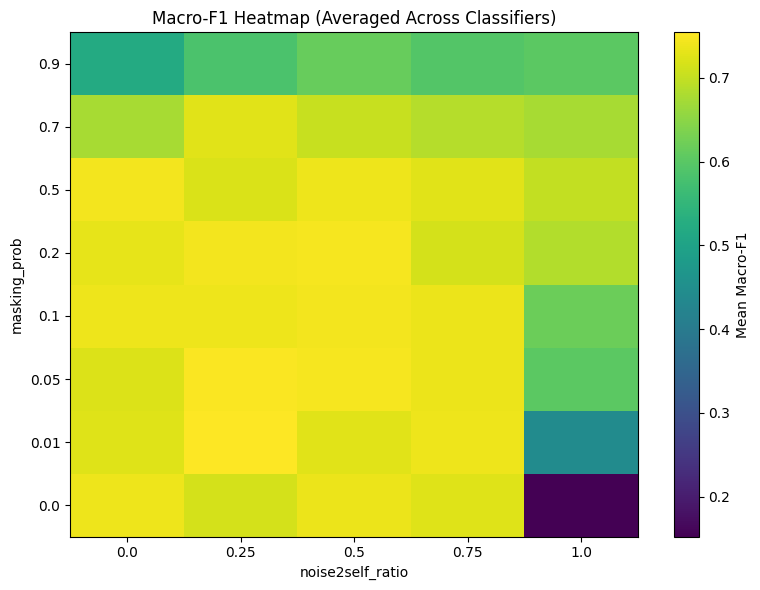

In [50]:
# Trend Visualization
pivot = overall.pivot(
    index="masking_prob",
    columns="noise2self_ratio",
    values="mean_macro_f1"
)

plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect="auto", origin="lower")
plt.colorbar(label="Mean Macro-F1")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("noise2self_ratio")
plt.ylabel("masking_prob")
plt.title("Macro-F1 Heatmap (Averaged Across Classifiers)")
plt.tight_layout()
plt.show()


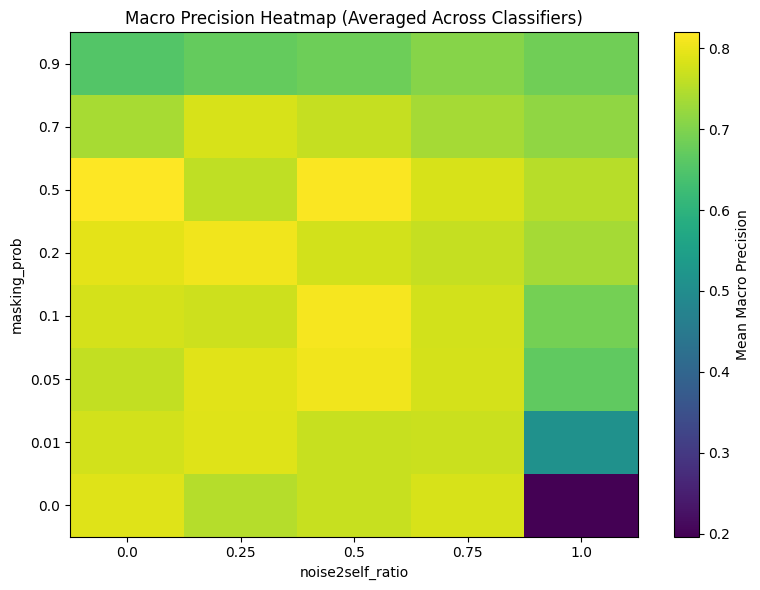

In [ ]:
# Trend Visualization
# Precison: out of all the times the model predicted a certain cell type, how many times was it correct? TP / (TP + FP)
pivot = overall.pivot(
    index="masking_prob",
    columns="noise2self_ratio",
    values="mean_macro_precision"
)

plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect="auto", origin="lower")
plt.colorbar(label="Mean Macro Precision")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("noise2self_ratio")
plt.ylabel("masking_prob")
plt.title("Macro Precision Heatmap (Averaged Across Classifiers)")
plt.tight_layout()
plt.show()


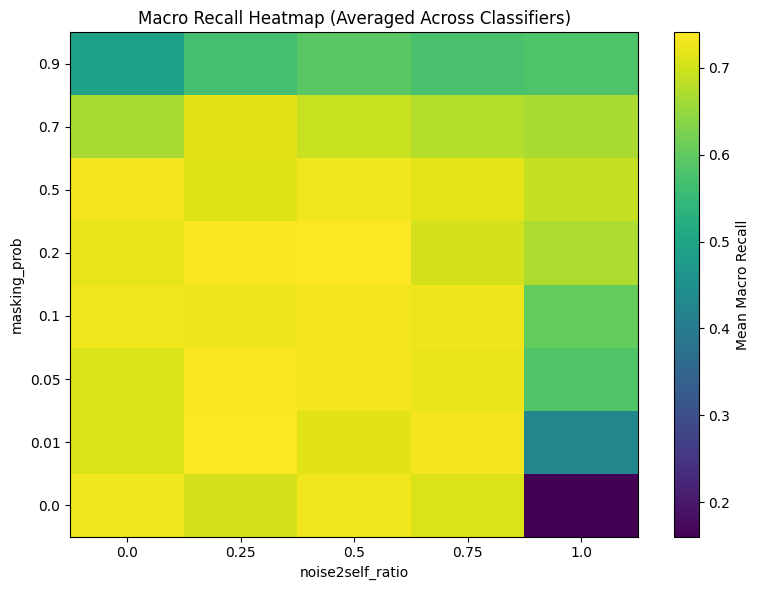

In [ ]:
# Trend Visualization
# Recall: Out of all actual instances of a certain cell type, how many times did the model correctly identify it? TP / (TP + FN)
pivot = overall.pivot(
    index="masking_prob",
    columns="noise2self_ratio",
    values="mean_macro_recall"
)

plt.figure(figsize=(8, 6))
plt.imshow(pivot, aspect="auto", origin="lower")
plt.colorbar(label="Mean Macro Recall")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("noise2self_ratio")
plt.ylabel("masking_prob")
plt.title("Macro Recall Heatmap (Averaged Across Classifiers)")
plt.tight_layout()
plt.show()

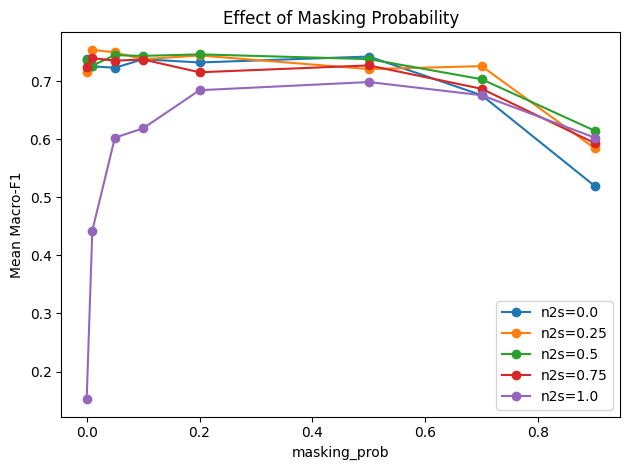

In [51]:
for n2s in sorted(overall["noise2self_ratio"].unique()):
    sub = overall[overall["noise2self_ratio"] == n2s]
    plt.plot(sub["masking_prob"], sub["mean_macro_f1"], marker="o", label=f"n2s={n2s}")

plt.xlabel("masking_prob")
plt.ylabel("Mean Macro-F1")
plt.title("Effect of Masking Probability")
plt.legend()
plt.tight_layout()
plt.show()


In [57]:
# I want to find trivially seperable cell types -- meaning even at low masking I achieve high f1-score.
# mean_f1: how seperable
# std_f1: how stable across different masking probabilities and noise2self ratios

celltype_mean = (
    df
    .groupby([
        "cell_type",
        "masking_prob",
        "noise2self_ratio"
    ])
    .agg(
        mean_f1=("f1_score", "mean"),
        std_f1=("f1_score", "std"),
        mean_recall=("recall", "mean"),
        mean_precision=("precision", "mean"),
    )
    .reset_index()
)
df

,classifier,masking_prob,noise2self_ratio,cell_type,precision,recall,f1_score,baseline_f1,delta_f1
0,LR,0.01,0.75,CD10+ B cells,0.891892,0.804878,0.846154,0.864198,0.018044
1,LR,0.01,0.75,CD14+ Monocytes,0.956154,0.980284,0.968069,0.969555,0.001486
2,LR,0.01,0.75,CD16+ Monocytes,0.285714,0.086957,0.133333,0.388889,0.255556
3,LR,0.01,0.75,CD20+ B cells,0.994774,0.993043,0.993908,0.987784,-0.006124
4,LR,0.01,0.75,CD4+ T cells,0.826594,0.965486,0.890658,0.882064,-0.008594
...,...,...,...,...,...,...,...,...,...
1915,SVM,0.50,0.50,Monocyte-derived dendritic cells,0.802083,0.802083,0.802083,0.791209,-0.010875
1916,SVM,0.50,0.50,NK cells,0.816901,0.758170,0.786441,0.823121,0.036681
1917,SVM,0.50,0.50,NKT cells,0.731939,0.701275,0.716279,0.762681,0.046402
1918,SVM,0.50,0.50,Plasma cells,0.857143,0.923077,0.888889,0.920000,0.031111


In [58]:
# Baseline seperability of cell types without low masking or noise2self
baseline = (
    celltype_mean
    .query("masking_prob <= 0.05")
    .groupby("cell_type")
    .agg(
        baseline_f1=("mean_f1", "mean"),
        baseline_var=("std_f1", "mean")
    )
    .reset_index()
)


In [59]:
baseline

,cell_type,baseline_f1,baseline_var
0,CD10+ B cells,0.769468,0.037812
1,CD14+ Monocytes,0.930454,0.016205
2,CD16+ Monocytes,0.047468,0.073606
3,CD20+ B cells,0.929979,0.027062
4,CD4+ T cells,0.861357,0.010646
5,CD8+ T cells,0.112217,0.085159
6,Erythrocytes,0.894410,0.022046
7,Erythroid progenitors,0.690053,0.014157
8,HSPCs,0.707490,0.025623
9,Megakaryocyte progenitors,0.575462,0.032027


In [60]:
# masking benefit score
# How much does a cell type benefit from representation learning?
peak = (
    celltype_mean
    .groupby("cell_type")
    .agg(peak_f1=("mean_f1", "max"))
    .reset_index()
)

celltype_effect = baseline.merge(peak, on="cell_type")
celltype_effect["delta_f1"] = (
    celltype_effect["peak_f1"] - celltype_effect["baseline_f1"]
)

celltype_effect.sort_values("delta_f1", ascending=False).head(10)


,cell_type,baseline_f1,baseline_var,peak_f1,delta_f1
14,Plasma cells,0.702281,0.063603,0.936135,0.233854
5,CD8+ T cells,0.112217,0.085159,0.328164,0.215947
0,CD10+ B cells,0.769468,0.037812,0.946190,0.176722
2,CD16+ Monocytes,0.047468,0.073606,0.211111,0.163643
10,Monocyte progenitors,0.554264,0.030865,0.697655,0.143391
9,Megakaryocyte progenitors,0.575462,0.032027,0.717708,0.142246
15,Plasmacytoid dendritic cells,0.830353,0.022629,0.950815,0.120462
8,HSPCs,0.707490,0.025623,0.819198,0.111708
11,Monocyte-derived dendritic cells,0.708158,0.020808,0.817369,0.109212
13,NKT cells,0.636394,0.030040,0.740340,0.103946


In [ ]:
celltype_effect.cell_type.tolist()

['CD10+ B cells',
 'CD14+ Monocytes',
 'CD16+ Monocytes',
 'CD20+ B cells',
 'CD4+ T cells',
 'CD8+ T cells',
 'Erythrocytes',
 'Erythroid progenitors',
 'HSPCs',
 'Megakaryocyte progenitors',
 'Monocyte progenitors',
 'Monocyte-derived dendritic cells',
 'NK cells',
 'NKT cells',
 'Plasma cells',
 'Plasmacytoid dendritic cells']

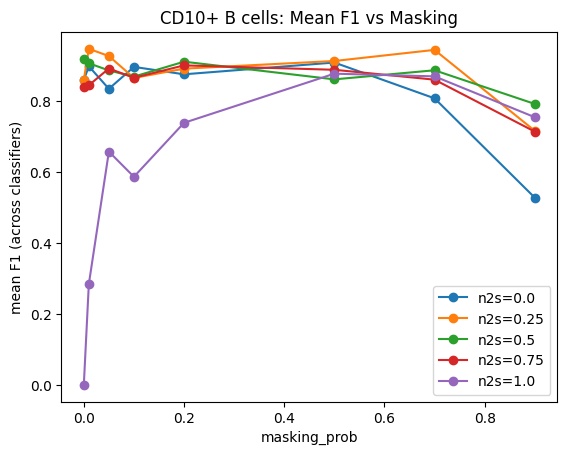

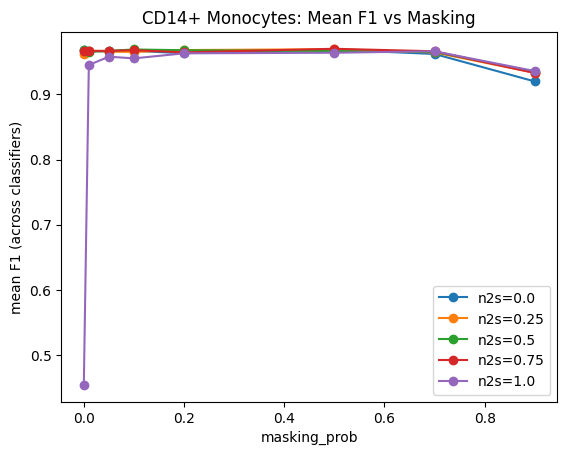

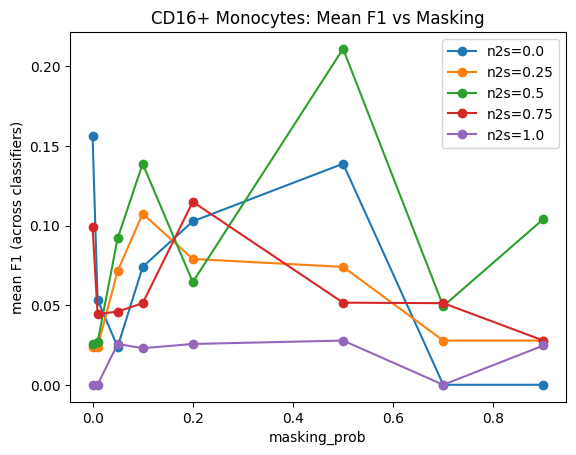

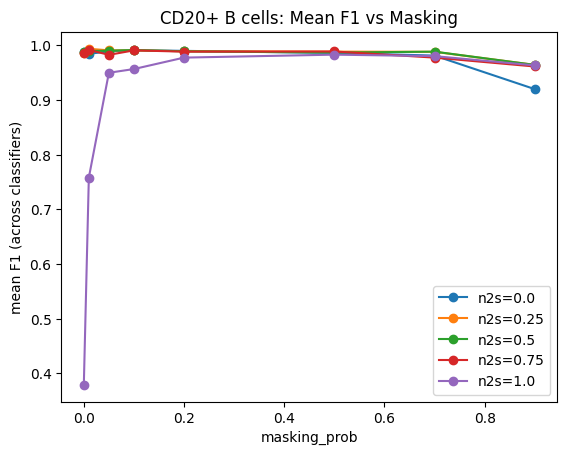

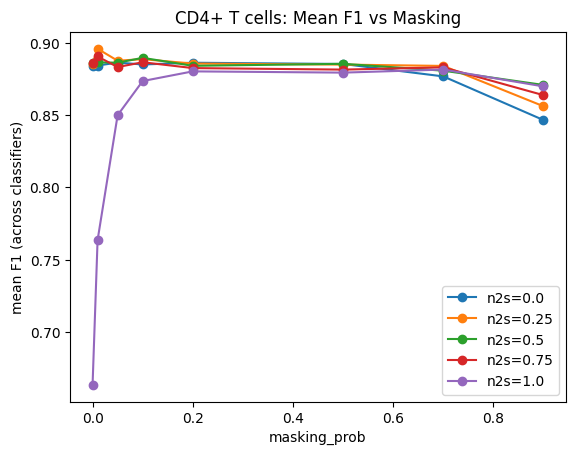

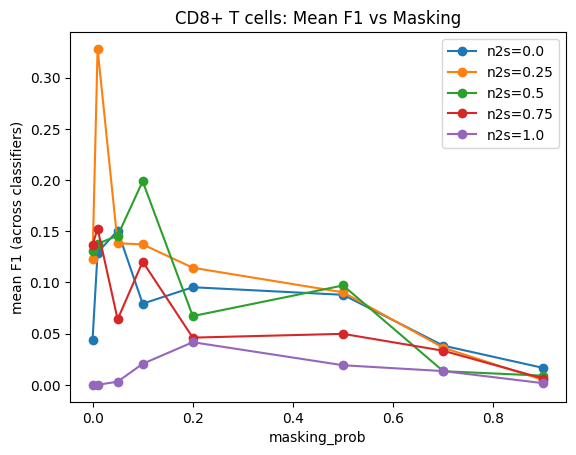

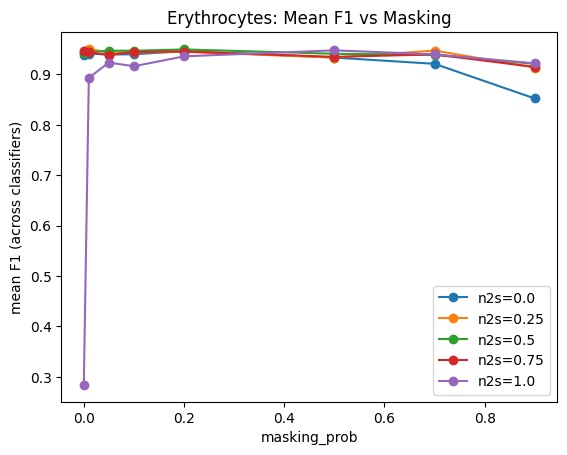

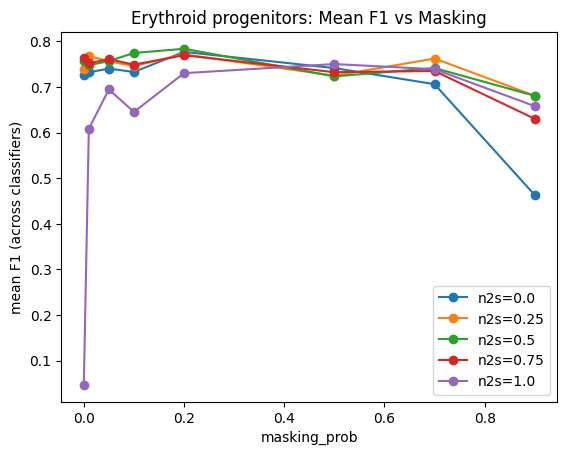

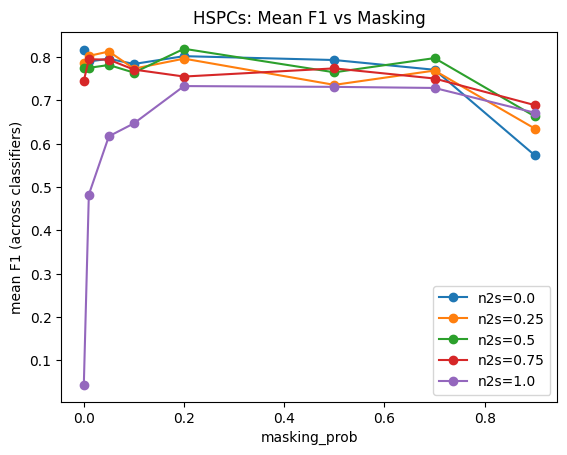

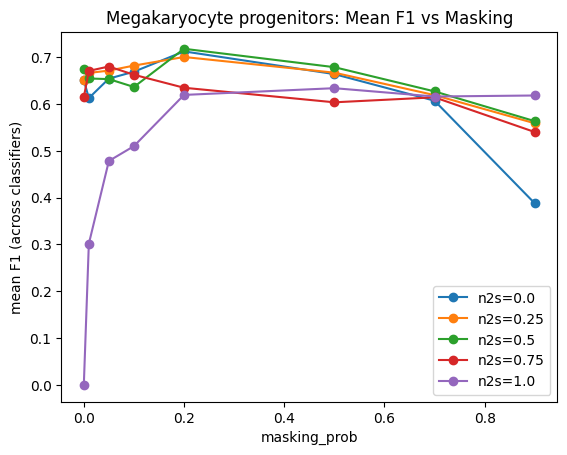

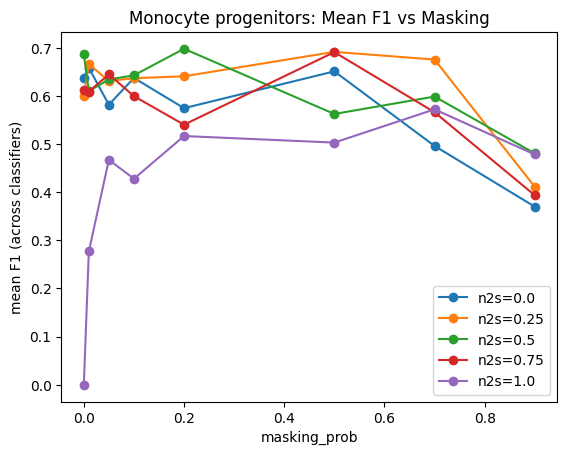

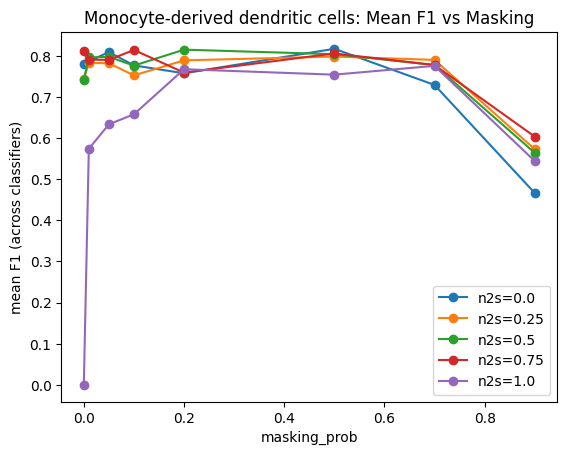

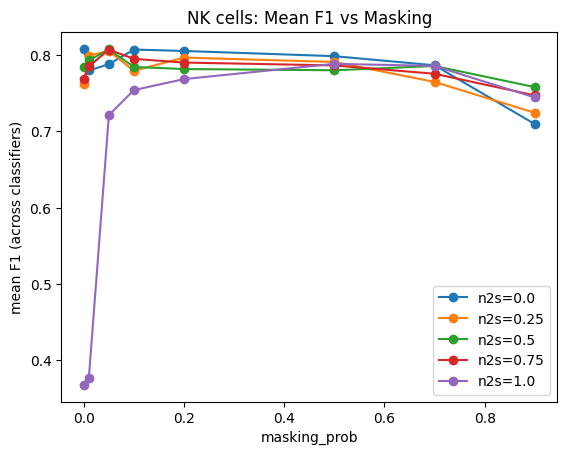

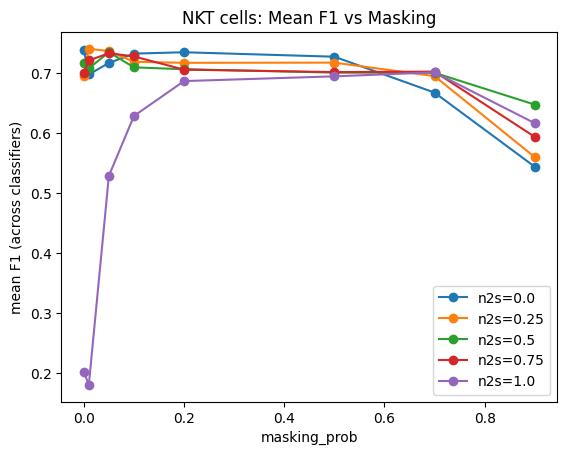

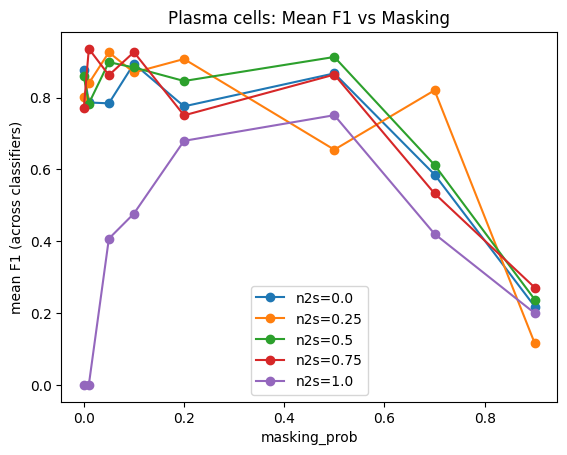

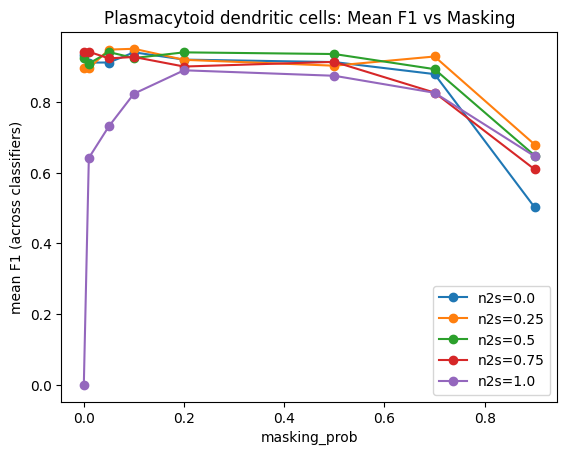

In [67]:
def plot_celltype(cell_type):
    sub = celltype_mean[celltype_mean["cell_type"] == cell_type]
    for n2s in sorted(sub["noise2self_ratio"].unique()):
        s = sub[sub["noise2self_ratio"] == n2s]
        plt.plot(
            s["masking_prob"],
            s["mean_f1"],
            marker="o",
            label=f"n2s={n2s}"
        )

    plt.title(f"{cell_type}: Mean F1 vs Masking")
    plt.xlabel("masking_prob")
    plt.ylabel("mean F1 (across classifiers)")
    plt.legend()
    plt.show()

# run this for CD14+ Monocytes, CD16+ Monocytes, Dendritic cells, Rare populations
for cell in celltype_effect.cell_type.tolist():
    plot_celltype(cell)



